# 06_Unsupervised_Model_Development_K-Means

In [1]:
# pip install --upgrade ipywidgets jupyter

In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
import umap
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import joblib

C:\Users\Tony\PyCharm Projects\cfpb_mortgage_complaints\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the parquet file
INPUT_PATH = '../data/processed/processed_narratives.parquet'
df_narratives = pd.read_parquet(INPUT_PATH)

In [4]:
df_narratives.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,cleaned_consumer_narrative,processed_narrative
0,2019-11-18,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,XXXX claimed they delivered a package to my ad...,NaN,DISCOVER BANK,MA,021XX,NaN,Consent provided,Web,2019-11-18,Closed with explanation,True,N/A,3442136,REDACTED claimed they delivered a package to m...,claimed delivered package address never receiv...
1,2020-04-10,Credit card or prepaid card,General-purpose prepaid card,Trouble using the card,Trouble getting information about the card,I got a Brinks Money pre-paid card in the mail...,Company has responded to the consumer and the ...,Netspend Corporation,IL,60657,NaN,Consent provided,Web,2020-04-14,Closed with explanation,True,N/A,3601853,I got a Brinks Money pre-paid card in the mail...,got brink money pre paid card mail assuming un...
2,2019-07-09,Credit card or prepaid card,Store credit card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,On XX/XX/XXXX I was called by a creditor Nelso...,NaN,Nelson Cruz & Associates LLC,TN,37043,NaN,Consent provided,Web,2019-07-09,Closed with explanation,True,N/A,3300820,On REDACTED_DATE I was called by a creditor Ne...,called creditor nelson cruz associate claimed ...
3,2020-07-10,Credit card or prepaid card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,Around XX/XX/2020 i XXXX XXXX XXXX opened a cr...,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,937XX,NaN,Consent provided,Web,2020-07-10,Closed with explanation,True,N/A,3739698,Around REDACTED / REDACTED /2020 i REDACTED RE...,around opened credit card account online capit...
4,2019-06-24,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,Equifax sent me credit card suggestions to hel...,NaN,"EQUIFAX, INC.",OR,971XX,NaN,Consent provided,Web,2019-06-24,Closed with explanation,True,N/A,3285243,Equifax sent me credit card suggestions to hel...,equifax sent credit card suggestion help impro...


In [5]:
# # Get unique Issue values, sort alphabetically
# # Export list to CSV
# issues_sorted = (
#     pd.DataFrame(
#         sorted(df_narratives['Issue'].dropna().unique()),
#         columns=['Issue']
#     )
# )
#
# # Export to CSV
# issues_sorted.to_csv(
#     'issues_sorted.csv',
#     index=False
# )
#
# print(f'Exported {len(issues_sorted):,} unique issues.')

In [6]:
# # Get unique Sub-issue values, sort alphabetically
# # Export list to CSV
# sub_issues_sorted = (
#     pd.DataFrame(
#         sorted(df_narratives['Sub-issue'].dropna().unique()),
#         columns=['Sub-issue']
#     )
# )
#
# # Export to CSV
# sub_issues_sorted.to_csv(
#     'sub-issues_sorted.csv',
#     index=False
# )
#
# print(f'Exported {len(sub_issues_sorted):,} unique sub-issues.')

In [7]:
# # Count unique Issue + Sub-issue combinations
# issue_subissue_combos = (
#     df_narratives[
#         ['Issue', 'Sub-issue']
#     ]
#     .drop_duplicates()
#     .sort_values(
#         by=['Issue', 'Sub-issue'],
#         na_position='last'
#     )
#     .reset_index(drop=True)
# )
#
# print(f'Unique Issue/Sub-issue combinations: {len(issue_subissue_combos):,}')
#
# issue_subissue_combos.head(20)

In [8]:
# Drop duplicate narratives
starting_records = len(df_narratives)

df_narratives = (
    df_narratives
    .drop_duplicates(subset=['processed_narrative'])
    .reset_index(drop=True)
)

ending_records = len(df_narratives)

print(f'Records before dropping duplicates: {starting_records:,}')
print(f'Duplicate narratives removed: {starting_records - ending_records:,}')
print(f'Records after dropping duplicates: {ending_records:,}')

Records before dropping duplicates: 419,635
Duplicate narratives removed: 21,631
Records after dropping duplicates: 398,004


In [9]:
# jpmorgan_count = (
#     df_narratives['processed_narrative']
#     .str.contains(r'\bjpmorgan\b', regex=True, na=False)
#     .sum()
# )
#
# print(f"Records containing 'jpmorgan': {jpmorgan_count:,}")

In [10]:
# domain_stopwords = {
#     'goldman',
#     'sachs',
#     'one',
#     'chase',
#     'well',
#     'fargo',
#     'capital',
#     'america',
#     'citibank',
#     'citi',
#     'jpmorgan',
#     'navy',
#     'federal',
#     'union',
#     'card',
#     'credit',
#     'account',
#     'bank',
# }
#
# custom_stopwords = ENGLISH_STOP_WORDS.union(domain_stopwords)

In [11]:
# If re-running notebook, load the trained Vectorizer
tfidf = joblib.load('../data/processed/tfidf_vectorizer.joblib')

# Transform rather than re-fit
X_tfidf = tfidf.transform(
    df_narratives['processed_narrative']
)

print(X_tfidf.shape)

(398004, 20000)


In [12]:
# # Get TF-IDF weights
# ### UNCOMMENT stop_words if you're using them ###
# tfidf = TfidfVectorizer(
#     # stop_words=list(custom_stopwords),
#     min_df=10,
#     max_df=0.95,
#     max_features=20000,
#     ngram_range=(1, 2),
# )
#
# X_tfidf = tfidf.fit_transform(df_narratives['processed_narrative'])
#
# print(X_tfidf.shape)

In [13]:
# Get top TF-IDF terms
feature_names = np.array(tfidf.get_feature_names_out())

mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()

top_tfidf_terms = (
    pd.DataFrame({
        'term': feature_names,
        'mean_tfidf': mean_tfidf
    })
    .sort_values('mean_tfidf', ascending=False)
)

top_tfidf_terms.head(25)

,term,mean_tfidf
121,account,0.051974
3260,card,0.035932
5360,credit,0.034115
2229,bank,0.033272
12925,payment,0.027906
3777,charge,0.021001
19588,would,0.019609
11298,money,0.019200
4057,check,0.018541
17741,time,0.018172


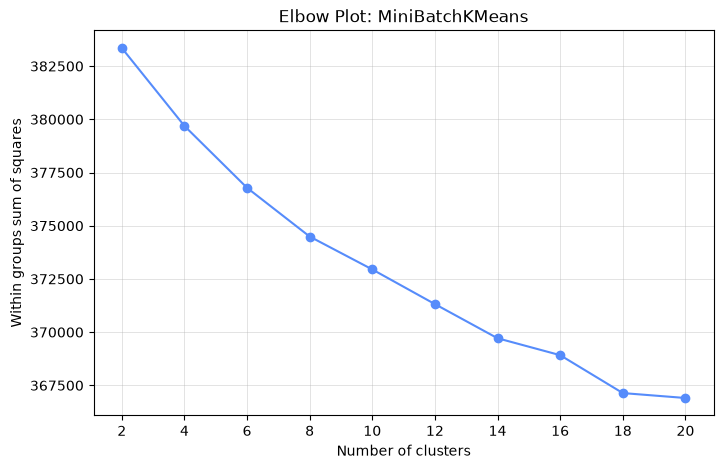

In [14]:
# Generate the elbow plot

# In the scikit-learn documentation, the inertia attribute is defined
# as the sum of squared distances of samples to their closest cluster
# center.

k_values = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
wgss = []

for k in k_values:
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        init='k-means++',
        batch_size=1000,
        random_state=42,
        n_init=1,
        max_iter=100
    )

    kmeans.fit(X_tfidf)

    # inertia_ = within-cluster sum of squares / WGSS
    wgss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wgss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Within groups sum of squares')
plt.title('Elbow Plot: MiniBatchKMeans')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [20]:
# Try different parameters for K-Means
n_clusters_grid = [10, 12, 14, 16, 18, 20]

sample_idx = np.random.RandomState(42).choice(
    X_tfidf.shape[0],
    size=10000,
    replace=False
)

X_sample_sparse = X_tfidf[sample_idx]
X_sample_dense = X_sample_sparse.toarray()

results = []

for k in n_clusters_grid:
    model = MiniBatchKMeans(
        n_clusters=k,
        init='k-means++',
        batch_size=1000,
        random_state=42,
        n_init=1,
        max_iter=100
    )

    cluster_labels = model.fit_predict(X_tfidf)
    cluster_sample = cluster_labels[sample_idx]

    results.append({
        'n_clusters': k,
        'inertia': model.inertia_,
        'silhouette_cosine': silhouette_score(
            X_sample_sparse,
            cluster_sample,
            metric='cosine'
        ),
        'davies_bouldin': davies_bouldin_score(
            X_sample_dense,
            cluster_sample
        ),
        'calinski_harabasz': calinski_harabasz_score(
            X_sample_dense,
            cluster_sample
        )
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(
        by=['silhouette_cosine', 'davies_bouldin', 'calinski_harabasz'],
        ascending=[False, True, False]
    )
)

results_df

,n_clusters,inertia,silhouette_cosine,davies_bouldin,calinski_harabasz
5,20,366905.796002,0.024924,7.611557,28.759153
4,18,367137.164607,0.023915,7.970636,29.922170
2,14,369713.003480,0.022509,7.894062,33.338830
3,16,368917.611730,0.022421,8.061888,30.580733
1,12,371317.227953,0.020237,8.032415,35.129509
0,10,372945.401009,0.019483,8.302003,37.822027


In [ ]:
# If re-running notebook, load the trained K-Means
kmeans = joblib.load('../data/processed/kmeans_clusters.joblib')

# Predict rather than re-fit
df_narratives['cluster'] = kmeans.fit_predict(X_tfidf)
df_narratives['cluster'].value_counts().sort_index()

In [22]:
# # Run K-Means with k = 18 based on elbow plot
# k = 18
#
# kmeans = MiniBatchKMeans(
#     n_clusters=k,
#     init='k-means++',
#     batch_size=1000,
#     random_state=42,
#     n_init=1,
#     max_iter=100
# )
#
# df_narratives['cluster'] = kmeans.fit_predict(X_tfidf)
# df_narratives['cluster'].value_counts().sort_index()

cluster
0     13275
1     22365
2     15859
3     29752
4      4786
5     13680
6      5579
7     18212
8      8814
9     68715
10    55831
11    16683
12    23104
13    17139
14    29248
15    18739
16    13047
17    23176
Name: count, dtype: int64

In [37]:
# Get top terms for each cluster
terms = np.array(tfidf.get_feature_names_out())

for cluster_num in range(k):
    top_indices = kmeans.cluster_centers_[cluster_num].argsort()[::-1][:8]
    top_terms = terms[top_indices]

    print(f'\nCluster {cluster_num}')
    print(', '.join(top_terms))


Cluster 0
interest, balance, payment, rate, charge, interest rate, month, paid

Cluster 1
payment, late, account, late payment, credit, made, due, make

Cluster 2
fargo, well fargo, well, account, claim, card, bank, transaction

Cluster 3
credit, card, credit card, account, report, credit report, limit, score

Cluster 4
navy, navy federal, federal, federal credit, credit union, union, credit, transaction

Cluster 5
bank america, america, bank, account, card, claim, credit, fraud

Cluster 6
cash app, cash, app, atm, money, account, machine, deposit

Cluster 7
chase, chase bank, account, bank, card, credit, charge, transaction

Cluster 8
reporting, credit, report, consumer, information, credit reporting, account, fcra

Cluster 9
bank, account, charge, transaction, money, card, time, claim

Cluster 10
account, bank, money, fund, closed, access, checking, told

Cluster 11
capital one, capital, one, account, credit, card, credit card, payment

Cluster 12
mortgage, loan, escrow, payment, in

In [24]:
# Add distance to assigned centroid to dataframe
distances = kmeans.transform(X_tfidf)
assigned_cluster = df_narratives['cluster'].values

df_narratives['distance_to_centroid'] = (
    distances[
        np.arange(len(df_narratives)),
        assigned_cluster
    ]
)

In [25]:
# Save fitted model and vectorizer

joblib.dump(
    tfidf,
    '../data/processed/tfidf_vectorizer.joblib'
)

joblib.dump(
    kmeans,
    '../data/processed/kmeans_clusters.joblib'
)

print('Model saved.')

Model saved.


# UMAP and t-SNE Visualizations

In [31]:
# Take sample to use for UMAP
sample_size = 20000

sample_idx = df_narratives.sample(
    n=sample_size,
    random_state=42
).index

X_sample = X_tfidf[sample_idx]

cluster_sample = (
    df_narratives
    .loc[sample_idx, 'cluster']
    .astype(int)
)

In [32]:
# Run SVD on 20k sample
svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

X_sample_svd = svd.fit_transform(X_sample)

In [33]:
# Run UMAP
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_umap = umap_model.fit_transform(X_sample_svd)

C:\Users\Tony\PyCharm Projects\cfpb_mortgage_complaints\.venv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


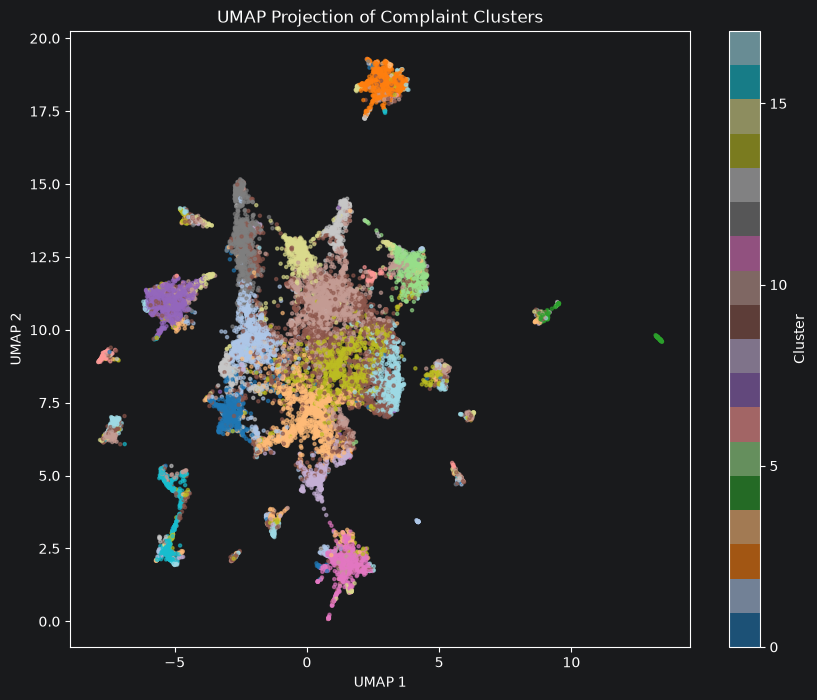

In [39]:
# Plot the UMAP
k = 18

cmap = plt.colormaps['tab20'].resampled(k)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=cluster_sample,
    cmap=cmap,
    s=5,
    alpha=0.6
)

plt.title('UMAP Projection of Complaint Clusters')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

cbar = plt.colorbar(
    scatter,
    ticks=range(0, k, 5)
)

cbar.set_label('Cluster')

plt.show()

## Commentary:
[Describe your workflow and feature representations]

Since K-Means clustering was applied to the text of beer reviews in SIADS 543, Assignment 2, I decided to try it on the consumer narratives in our dataset [add citation]. I had two goals in mind: (1) to see if features could be generated that would help the supervised learning model, and (2) to identify potential hidden themes in the customer complaints. I generated an elbow plot to try to find the optimal value of k. I included the following range: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]. Based on the elbow plot, the bend appears to occur at 16 or 18. I did a parameter search for the silhouette score over a narrower range for k: [10, 12, 14, 16, 18, 20]. The silhouette scores were quite low. The highest score was for k = 20 with a score of 0.025. As k = 18 was extremely close at 0.024, I decided to maintain that as the parameter value.

As many of the clusters had company names as top terms, I tried removing these to see how performance would change. Using company names as stop words causes a decrease in silhouette scores at k = 18, from 0.024 to 0.012. [Identify differences in cluster top terms and themes uncovered].

Compared to the UMAP with company stop words, there are more distinct clusters when leave the company words in. The clusters with the most visual separation appear to be company-specific. The most visually distinct clusters in the stopword model appear to be those related to overdrafts and late payments.
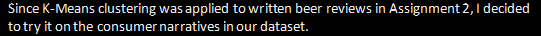
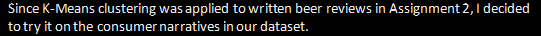
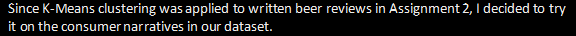

In [35]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample_svd)

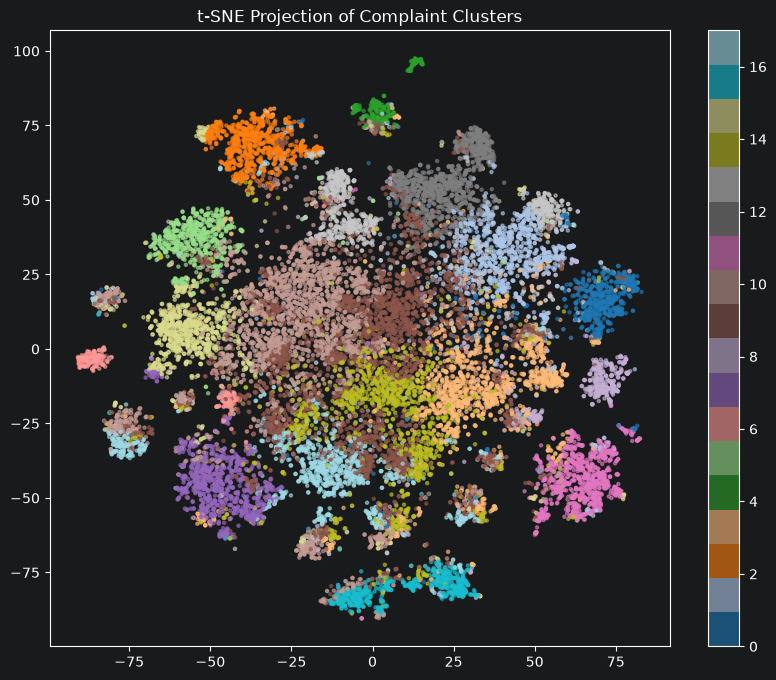

In [38]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=cluster_sample,
    cmap=plt.colormaps['tab20'].resampled(18),
    s=5,
    alpha=0.6
)

plt.colorbar(scatter)
plt.title('t-SNE Projection of Complaint Clusters')
plt.show()

## Experimenting with Different Values of K

In [87]:
# # Run K-Means mini-batching and add cluster ID's to dataframe
# k = 10
#
# kmeans = MiniBatchKMeans(
#     n_clusters=k,
#     random_state=42,
#     batch_size=1000,
#     n_init='auto'
# )
#
# clusters = kmeans.fit_predict(X_tfidf)
#
# df_narratives['cluster'] = clusters
#
# df_narratives['cluster'].value_counts().sort_index()

In [88]:
# # Try different values of k (5, 10, 15, 20)
#
# # Use a sample for silhouette scoring to avoid memory/runtime issues
# sample_size = 10_000
#
# sample_idx = df_narratives.sample(
#     n=sample_size,
#     random_state=42
# ).index
#
# X_sample = X_tfidf[sample_idx]
#
# k_values = [5, 10, 15, 20]
#
# results = []
#
# for k in k_values:
#     print(f'Running MiniBatchKMeans for k={k}...')
#
#     kmeans = MiniBatchKMeans(
#         n_clusters=k,
#         random_state=42,
#         batch_size=1000,
#         n_init='auto'
#     )
#
#     cluster_labels = kmeans.fit_predict(X_tfidf)
#
#     sample_labels = cluster_labels[sample_idx]
#
#     sil_score = silhouette_score(
#         X_sample,
#         sample_labels,
#         metric='cosine'
#     )
#
#     results.append({
#         'k': k,
#         'silhouette_score': sil_score,
#         'inertia': kmeans.inertia_
#     })
#
#     print(f'k={k}, silhouette={sil_score:.4f}, inertia={kmeans.inertia_:.2f}')
#
# k_results = pd.DataFrame(results)
#
# k_results

In [89]:
# # Try different values of k (20, 25, 30)
#
# # Use a sample for silhouette scoring to avoid memory/runtime issues
# sample_size = 10_000
#
# sample_idx = df_narratives.sample(
#     n=sample_size,
#     random_state=42
# ).index
#
# X_sample = X_tfidf[sample_idx]
#
# k_values = [20, 25, 30]
#
# results = []
#
# for k in k_values:
#     print(f'Running MiniBatchKMeans for k={k}...')
#
#     kmeans = MiniBatchKMeans(
#         n_clusters=k,
#         random_state=42,
#         batch_size=1000,
#         n_init='auto'
#     )
#
#     cluster_labels = kmeans.fit_predict(X_tfidf)
#
#     sample_labels = cluster_labels[sample_idx]
#
#     sil_score = silhouette_score(
#         X_sample,
#         sample_labels,
#         metric='cosine'
#     )
#
#     results.append({
#         'k': k,
#         'silhouette_score': sil_score,
#         'inertia': kmeans.inertia_
#     })
#
#     print(f'k={k}, silhouette={sil_score:.4f}, inertia={kmeans.inertia_:.2f}')
#
# k_results = pd.DataFrame(results)
#
# k_results

In [90]:
# # Re-run K-Means with k = 30
# k = 30
#
# kmeans_30 = MiniBatchKMeans(
#     n_clusters=k,
#     random_state=42,
#     batch_size=1000,
#     n_init='auto'
# )
#
# df_narratives['cluster_30'] = kmeans_30.fit_predict(X_tfidf)

In [91]:
# # Get top terms for each cluster
# terms = np.array(tfidf.get_feature_names_out())
#
# for cluster_num in range(k):
#     top_indices = kmeans_30.cluster_centers_[cluster_num].argsort()[::-1][:15]
#     top_terms = terms[top_indices]
#
#     print(f'\nCluster {cluster_num}')
#     print(', '.join(top_terms))

In [92]:
# # Make elbow plot
#
# # If you already have k_results from the previous runs:
# k_results_all = pd.DataFrame({
#     'k': [5, 10, 15, 20, 25, 30],
#     'inertia': [
#         501625.757038,
#         493061.541536,
#         484974.411374,
#         477933.852704,
#         473501.325696,
#         469830.685334
#     ],
#     'silhouette_score': [
#         0.017681,
#         0.020211,
#         0.024968,
#         0.032750,
#         0.034799,
#         0.040312
#     ]
# })
#
# plt.figure(figsize=(8, 5))
#
# plt.plot(
#     k_results_all['k'],
#     k_results_all['inertia'],
#     marker='o'
# )
#
# plt.title('Elbow Plot for MiniBatchKMeans')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia')
# plt.xticks(k_results_all['k'])
# plt.show()

In [93]:
# # Reuse the same 10k sample for silhouette scoring
# sample_idx = df_narratives.sample(
#     n=10000,
#     random_state=42
# ).index
#
# X_sample = X_tfidf[sample_idx]
#
# k_values = [10, 20, 30, 40, 50, 75]
#
# results = []
#
# for k in k_values:
#
#     print(f'Running MiniBatchKMeans for k={k}...')
#
#     model = MiniBatchKMeans(
#         n_clusters=k,
#         random_state=42,
#         batch_size=1000,
#         n_init='auto'
#     )
#
#     labels = model.fit_predict(X_tfidf)
#
#     sil = silhouette_score(
#         X_sample,
#         labels[sample_idx],
#         metric='cosine'
#     )
#
#     results.append({
#         'k': k,
#         'silhouette_score': sil,
#         'inertia': model.inertia_
#     })
#
#     print(
#         f'k={k}, '
#         f'silhouette={sil:.4f}, '
#         f'inertia={model.inertia_:.2f}'
#     )
#
# k_results = pd.DataFrame(results)
#
# print(k_results)

In [94]:
df_narratives.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,...,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,cleaned_consumer_narrative,processed_narrative,cluster,distance_to_centroid
0,2019-11-18,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,XXXX claimed they delivered a package to my ad...,NaN,DISCOVER BANK,MA,021XX,...,Web,2019-11-18,Closed with explanation,True,N/A,3442136,REDACTED claimed they delivered a package to m...,claimed delivered package address never receiv...,11,0.992864
1,2020-04-10,Credit card or prepaid card,General-purpose prepaid card,Trouble using the card,Trouble getting information about the card,I got a Brinks Money pre-paid card in the mail...,Company has responded to the consumer and the ...,Netspend Corporation,IL,60657,...,Web,2020-04-14,Closed with explanation,True,N/A,3601853,I got a Brinks Money pre-paid card in the mail...,got brink money pre paid card mail assuming un...,3,0.998468
2,2019-07-09,Credit card or prepaid card,Store credit card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,On XX/XX/XXXX I was called by a creditor Nelso...,NaN,Nelson Cruz & Associates LLC,TN,37043,...,Web,2019-07-09,Closed with explanation,True,N/A,3300820,On REDACTED_DATE I was called by a creditor Ne...,called creditor nelson cruz associate claimed ...,44,0.978543
3,2020-07-10,Credit card or prepaid card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,Around XX/XX/2020 i XXXX XXXX XXXX opened a cr...,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,937XX,...,Web,2020-07-10,Closed with explanation,True,N/A,3739698,Around REDACTED / REDACTED /2020 i REDACTED RE...,around opened credit card account online capit...,25,0.852135
4,2019-06-24,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,Equifax sent me credit card suggestions to hel...,NaN,"EQUIFAX, INC.",OR,971XX,...,Web,2019-06-24,Closed with explanation,True,N/A,3285243,Equifax sent me credit card suggestions to hel...,equifax sent credit card suggestion help impro...,44,0.963603


In [95]:
df_narratives.info()

<class 'pandas.DataFrame'>
RangeIndex: 398004 entries, 0 to 398003
Data columns (total 22 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Date received                 398004 non-null  datetime64[ms]
 1   Product                       398004 non-null  str           
 2   Sub-product                   398004 non-null  str           
 3   Issue                         398004 non-null  str           
 4   Sub-issue                     398004 non-null  str           
 5   Consumer complaint narrative  398004 non-null  str           
 6   Company public response       188952 non-null  str           
 7   Company                       398004 non-null  str           
 8   State                         398004 non-null  str           
 9   ZIP code                      398004 non-null  str           
 10  Tags                          83030 non-null   str           
 11  Consumer consent provide

In [102]:
df_narratives['cluster'].value_counts().sort_index(ascending=False)

cluster
59    14692
58     3797
57     3195
56     3186
55     8323
54        1
53     1611
52    14365
51      736
50     2580
49    11878
48        1
47     3795
46     4354
45    12061
44    23788
43     5717
42     6413
41     4910
40    13208
39     5635
38     6356
37     4491
36     5717
35    15604
34     6427
33        1
32    10975
31     2126
30        1
29        1
28     3134
27        1
26     6900
25    14668
24     1664
23     4408
22    11651
21     1695
20     5364
19     2209
18    11349
17        1
16     8986
15    10847
14        1
13     1379
12    10705
11    12998
10    10771
9      2682
8         2
7      2735
6     23631
5      2912
4      1166
3     45850
2         1
1       497
0      3852
Name: count, dtype: int64

In [96]:
OUTPUT_PATH = '../data/processed/clustered_narratives.parquet'

df_narratives.to_parquet(
    OUTPUT_PATH,
    index=False
)